# Credit Card Fraud Detection

## 1.Import Libraries

In [2]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

#Visualisation
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Gestion de déséquilibre 
from imblearn.over_sampling import SMOTE

#Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
# Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Configuration du style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
sns.set_theme(style="darkgrid", palette="deep")

## 2.Load Data

In [7]:
#Chargement des données
data = pd.read_csv("credit_card_fraud_10k.csv")
print("Shape : ",data.shape)
display(data.head(10))

Shape :  (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [8]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None


In [9]:
print(data.describe())

       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0.000000     

# Description du Dataset – Système de Détection de Fraude

## 1. Vue d’ensemble

Ce dataset simule un environnement de détection de fraude dans un contexte fintech.  
Chaque ligne correspond à une transaction financière unique décrite par des variables transactionnelles, comportementales, contextuelles et liées au risque.

La variable cible est :

- is_fraud : variable binaire (0 = transaction légitime, 1 = transaction frauduleuse)

L’objectif est de construire un modèle de classification supervisée capable d’identifier les transactions suspectes.

---

# Analyse détaillée des colonnes

## 1. transaction_id

Type : Identifiant (catégoriel)

Rôle :
Identifiant unique de chaque transaction.

Utilisation en machine learning :
- Non utilisée pour l’entraînement du modèle.
- Sert uniquement à la traçabilité.

Importance métier :
- Audit
- Investigation
- Communication avec le client
- Référence interne dans le système bancaire

---

## 2. amount

Type : Numérique continu

Description :
Montant monétaire de la transaction.

Analyse fraude :
Le montant est un indicateur central dans les systèmes antifraude.  
Les transactions frauduleuses peuvent être :
- De montant élevé (tentative de maximisation du gain)
- De faible montant (transactions test avant attaque principale)

Importance en machine learning : Très élevée

Impact métier :
Risque financier direct pour l’institution bancaire.

---

## 3. transaction_hour

Type : Numérique discret (0–23)

Description :
Heure à laquelle la transaction a été réalisée.

Analyse fraude :
Les transactions frauduleuses se produisent fréquemment :
- À des heures inhabituelles
- Tard dans la nuit
- En dehors du comportement normal du client

Importance en machine learning : Moyenne

Impact métier :
Permet d’identifier des anomalies comportementales temporelles.

---

## 4. merchant_category

Type : Catégorielle

Description :
Catégorie du commerçant (exemple : électronique, voyage, alimentation, services digitaux).

Analyse fraude :
Certaines catégories sont historiquement plus exposées à la fraude :
- Produits électroniques
- E-commerce
- Biens numériques

Importance en machine learning : Élevée

Impact métier :
Permet d’intégrer une pondération sectorielle dans le score de risque.

---

## 5. foreign_transaction

Type : Binaire (0 = nationale, 1 = internationale)

Description :
Indique si la transaction est effectuée à l’étranger.

Analyse fraude :
Les transactions internationales inattendues sont souvent associées à des comportements frauduleux.

Importance en machine learning : Élevée

Impact métier :
Peut déclencher une authentification forte ou une vérification supplémentaire.

---

## 6. location_mismatch

Type : Binaire

Description :
Indique si la localisation de la transaction diffère de la localisation habituelle du client.

Exemple :
- Carte principalement utilisée au Maroc
- Transaction soudaine dans un autre pays

Analyse fraude :
C’est un indicateur très puissant d’anomalie géographique.  
Il détecte les incohérences spatiales et les comportements impossibles ou improbables.

Importance en machine learning : Très élevée

Impact métier :
Feature stratégique pour les équipes antifraude.

---

## 7. device_trust_score

Type : Numérique (score entre 0 et 1)

Description :
Score de confiance attribué à l’appareil utilisé pour la transaction.

- Score élevé : appareil connu
- Score faible : nouvel appareil ou appareil suspect

Analyse fraude :
Les fraudeurs utilisent souvent :
- Nouveaux appareils
- Navigateurs anonymes
- Réseaux masqués

Importance en machine learning : Très élevée

Impact métier :
Indicateur clé dans les systèmes modernes de détection comportementale.

---

## 8. velocity_last_24h

Type : Numérique

Description :
Nombre de transactions effectuées par la même carte durant les dernières 24 heures.

Analyse fraude :
Une augmentation soudaine du volume de transactions peut indiquer :
- Attaque automatisée
- Tentative de fraude en rafale
- Compromission récente de la carte

Importance en machine learning : Très élevée

Impact métier :
Permet la détection des comportements anormaux de type "burst activity".

---

## 9. cardholder_age

Type : Numérique

Description :
Âge du titulaire de la carte.

Analyse fraude :
L’âge est généralement un faible prédicteur direct de fraude.  
La fraude dépend principalement du comportement transactionnel et non du profil démographique.

Importance en machine learning : Faible à modérée

Impact métier :
Peut être utilisé pour des analyses segmentées, mais son impact direct reste limité.

---

## 10. is_fraud (Variable cible)

Type : Binaire

0 : Transaction légitime  
1 : Transaction frauduleuse

Rôle :
Variable cible utilisée pour entraîner le modèle supervisé.

Signification métier :
Indique si la transaction a été confirmée comme frauduleuse après investigation.

---

# Synthèse globale

Ce dataset combine plusieurs dimensions essentielles :

1. Données transactionnelles :
   - amount
   - transaction_hour

2. Indicateurs comportementaux :
   - velocity_last_24h
   - device_trust_score

3. Indicateurs géographiques :
   - foreign_transaction
   - location_mismatch

4. Informations client :
   - cardholder_age

Cette combinaison permet de construire un modèle de scoring antifraude cohérent, exploitable dans un système d’aide à la décision destiné à un analyste bancaire.

Le dataset est structuré de manière logique pour un projet fintech intégrant :
- Modélisation prédictive
- Analyse de risque
- Workflow d’investigation humaine


In [11]:
df = data.copy()

In [12]:
#les valeurs manquantes par colonnes 
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

### Analyse des valeurs manquantes
Après vérification , aucune valeur manquante n’a été détectée dans le jeu de données. 
Par conséquent, aucune étape d’imputation ou de traitement des valeurs manquantes n’est nécessaire à ce stade de l’analyse.

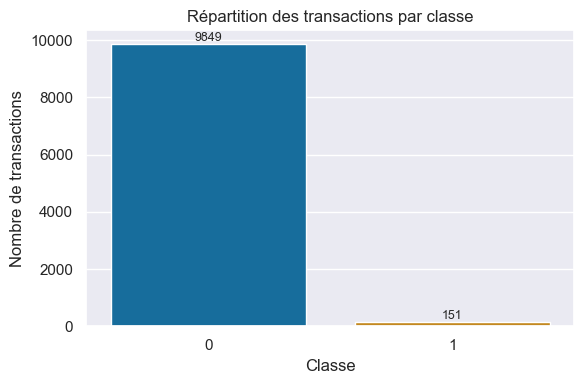

In [13]:
# On récupère l'ordre des classes selon leur fréquence (du plus fréquent au moins fréquent)
# value_counts() compte le nombre d’occurrences de chaque classe
# .index permet d'obtenir uniquement les étiquettes des classes dans cet ordre
ordre_classe = df["is_fraud"].value_counts().index


# On définit la taille de la figure pour un meilleur affichage
plt.figure(figsize=(6,4))


# Création du graphique countplot
# data=df : dataset utilisé
# x="Class" : variable à afficher sur l’axe X
# order=ordre_classe : impose l’ordre des classes (important si dataset déséquilibré)
# palette="colorblind" : palette adaptée aux personnes daltoniennes
ax = sns.countplot(
    data=df,
    x="is_fraud",
    order=ordre_classe,
    palette="colorblind"
)

ax.set_title("Répartition des transactions par classe")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre de transactions")


# Boucle pour ajouter les annotations (le nombre exact au-dessus de chaque barre)
# ax.patches contient toutes les barres du graphique
for p in ax.patches:
    
    # On récupère la hauteur de chaque barre
    # Dans un countplot vertical, la hauteur correspond au nombre d’observations
    height = p.get_height()
    
    # On ajoute une annotation au-dessus de chaque barre
    ax.annotate(
        f"{int(height)}",  # texte affiché (converti en entier)
        
        # Position de l’annotation :
        # X = centre de la barre
        # Y = hauteur de la barre
        (p.get_x() + p.get_width() / 2, height),
        
        ha="center",  # alignement horizontal centré
        va="bottom",  # alignement vertical au-dessus de la barre
        fontsize=9    # taille de police
    )


# Ajuste automatiquement les marges pour éviter que le texte soit coupé
plt.tight_layout()

# Affiche le graphique
plt.show()


# Analyse de la Répartition des Classes – Dataset Fraud (10k)

## 1. Distribution Observée

D’après le graphique :

- Classe 0 (Transactions légitimes) : 9 849
- Classe 1 (Transactions frauduleuses) : 151

### Taux de fraude

Taux de fraude = 151 / (9849 + 151)  
Taux ≈ 1,51 %

Le dataset est fortement déséquilibré, avec environ :

Ratio ≈ 65:1  
(65 transactions légitimes pour 1 fraude)

---

## 2. Impact sur la Modélisation

### Problème principal

Un modèle naïf prédisant toujours "0" obtiendrait :

Accuracy ≈ 98,49 %

Ce qui est trompeur et inutilisable en contexte bancaire.

L’accuracy n’est donc pas une métrique pertinente.

---

## 3. Métriques adaptées au problème

Dans un contexte de fraude, les métriques prioritaires sont :

- Recall (Fraud) → Capacité à détecter les fraudes
- Precision (Fraud) → Éviter les faux positifs excessifs
- F1-score → Équilibre entre précision et rappel
- ROC-AUC
- PR-AUC (plus pertinente en cas de classes rares)

L’objectif métier est généralement :

Maximiser le recall fraude tout en contrôlant le taux de faux positifs.

---

## 4. Risques si le déséquilibre n’est pas traité

Sans correction :

- Le modèle apprend majoritairement la classe 0
- Sous-détection des fraudes
- Mauvaise généralisation
- Faible valeur business

---

## 5. Stratégies recommandées

Pour ce niveau de déséquilibre (~1.5 %) :

- SMOTE (oversampling)
- class_weight='balanced'
- Optimisation du seuil de décision
- Analyse de la courbe Precision-Recall
- Validation croisée stratifiée

---

## 6. Interprétation Business

Un taux de fraude de 1–2 % est cohérent avec des datasets pédagogiques ou simulés.

Dans un contexte réel bancaire :

- La fraude est rare
- Le coût d’un faux négatif (fraude non détectée) est élevé
- Le coût d’un faux positif (transaction bloquée à tort) impacte l’expérience client

Le modèle doit donc être calibré selon une stratégie de gestion du risque.

---

## Conclusion

Ce dataset présente un déséquilibre significatif mais réaliste pour un projet de détection de fraude.

Il est adapté pour :

- Démonstration académique
- Prototype fintech
- Développement d’un système d’aide à la décision pour analyste bancaire

Il nécessite cependant une gestion rigoureuse du déséquilibre et une évaluation basée sur des métriques adaptées aux classes rares.

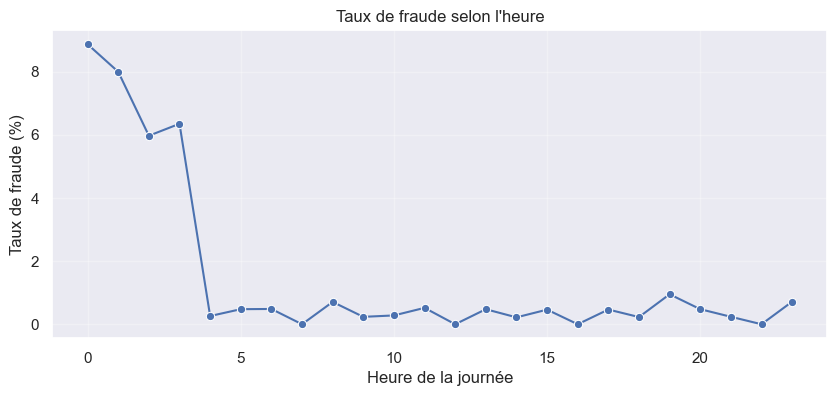

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du taux de fraude par heure
fraud_rate_per_hour = (
    df.groupby('transaction_hour')['is_fraud']
      .mean() * 100
)

# Visualisation
plt.figure(figsize=(10,4))

sns.lineplot(
    x=fraud_rate_per_hour.index,
    y=fraud_rate_per_hour.values,
    marker="o"
)

plt.title("Taux de fraude selon l'heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Taux de fraude (%)")

plt.grid(alpha=0.3)
plt.show()

## Analyse du taux de fraude selon l'heure de la journée

### 1. Observation générale

L’analyse du taux de fraude par heure révèle une forte variation temporelle.

On observe un pic extrêmement élevé entre :

- 00h et 03h du matin

Le taux atteint près de 9 % à minuit, puis diminue progressivement jusqu’à 04h.

À partir de 04h du matin, le taux chute drastiquement et reste globalement inférieur à 1 % durant la majorité de la journée.

---

### 2. Interprétation des résultats

#### Période à très haut risque : 00h – 03h

Ces heures présentent :

- Un taux de fraude significativement supérieur à la moyenne globale (~1.5 %)
- Une concentration anormale d’activités frauduleuses

Cela peut s’expliquer par :

- Moins de vigilance des clients
- Activité humaine réduite
- Exploitation de créneaux nocturnes par les fraudeurs

#### Période à risque faible : 04h – 23h

Durant la journée :

- Le taux de fraude reste relativement stable
- Les variations sont faibles
- Le comportement transactionnel semble plus normalisé

---

### 3. Insight Data Science

La variable `transaction_hour` est une feature temporelle fortement discriminante.

Elle permet :

- D’améliorer la séparation des classes
- D’introduire une dimension comportementale
- De capter des patterns cycliques

Une transformation pertinente pourrait être :

- Création d’une variable binaire "night_transaction"
- Ou encodage cyclique (sin/cos) pour modèle avancé

---

### 4. Implication Business (Fintech)

Dans un contexte bancaire réel :

Les transactions effectuées entre 00h et 03h devraient :

- Recevoir un score de risque plus élevé
- Déclencher une authentification supplémentaire
- Être priorisées pour revue analyste

Cependant, l’heure seule ne doit jamais suffire pour bloquer une transaction.

Le risque doit être évalué en combinaison avec :

- Location mismatch
- Foreign transaction
- Device trust score
- Velocity des transactions

---

### 5. Conclusion

L’analyse temporelle met en évidence un comportement frauduleux concentré durant les heures nocturnes.

La variable `transaction_hour` constitue un signal prédictif pertinent et exploitable dans un système de détection de fraude en temps réel.

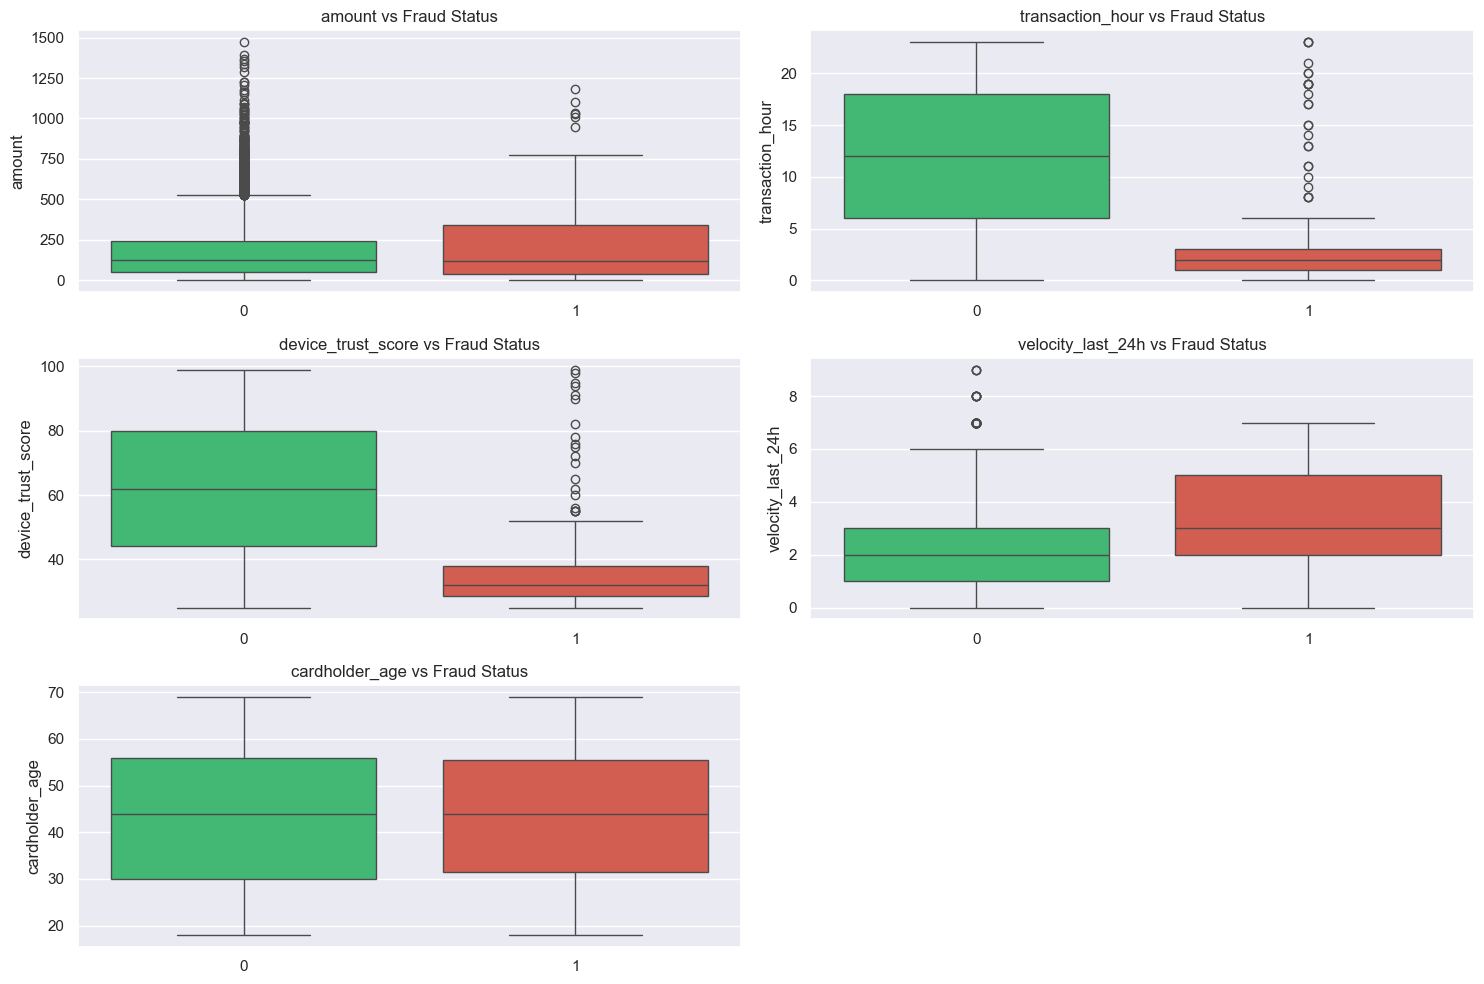

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['amount', 'transaction_hour', 'device_trust_score',
                  'velocity_last_24h', 'cardholder_age']

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,2,i)
    
    sns.boxplot(
        x='is_fraud',
        y=col,
        data=df,
        palette=['#2ecc71', '#e74c3c']  # vert = legit, rouge = fraud
    )
    
    plt.title(f'{col} vs Fraud Status')
    plt.xlabel('')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


#  Analyse Comparative des Variables vs Fraud Status

---

# 1️. Amount vs Fraud Status

##  Question Analytique
Les transactions frauduleuses ont-elles des montants significativement différents des transactions légitimes ?

---

##  Analyse du Boxplot

Un boxplot montre 5 éléments :

- **Médiane** : ligne centrale dans la boîte  
- **Q1 (25%)**  
- **Q3 (75%)**  
- **Whiskers** : étendue hors valeurs extrêmes  
- **Outliers** : points isolés  

###  Observation

- La médiane des fraudes semble légèrement différente mais reste proche de celle des transactions normales.
- L’IQR (Q3 - Q1) est plus large pour les fraudes → dispersion plus importante.
- Présence importante d’outliers dans les deux classes.
- Les transactions normales présentent aussi des montants très élevés.

---

## Interprétation Métier

Contrairement à une intuition classique :

- La fraude ne concerne pas uniquement de gros montants.
- Beaucoup de fraudes sont réalisées avec des montants modérés.
- Les fraudeurs peuvent volontairement rester dans des plages "normales" pour éviter la détection.

La variable `Amount` seule n’est pas fortement discriminante.

---

##  Conclusion

Le montant contribue au signal de fraude,  
mais il doit être combiné avec d'autres variables comportementales.

---

# 2️. Transaction Hour vs Fraud Status

##  Question Analytique
Les fraudes se produisent-elles à des moments spécifiques de la journée ?

---

##  Analyse du Boxplot

###  Observation

- La médiane des transactions normales est autour du milieu de la journée.
- La médiane des fraudes est nettement plus basse.
- Les fraudes sont concentrées dans une plage horaire plus restreinte.
- Plusieurs outliers indiquent quelques fraudes à des heures inhabituelles.

---

##  Interprétation Métier

Les fraudes semblent davantage se produire :

- Tôt le matin
- Ou à des heures atypiques

Cela peut s'expliquer par :

- Moins de surveillance humaine
- Moins d’activité bancaire
- Tentatives d’éviter les alertes en temps réel

---

##  Conclusion

`Transaction_hour` est une variable fortement discriminante.  
Elle capture un comportement temporel anormal.

---

# 3️. Device Trust Score vs Fraud Status

##  Question Analytique
Les fraudes sont-elles associées à des appareils moins fiables ?

---

##  Analyse du Boxplot

###  Observation

- La médiane des transactions légitimes est élevée (~60-70).
- La médiane des fraudes est très basse (~30).
- Séparation très claire entre les deux distributions.
- Faible chevauchement entre les boîtes.
- Plusieurs outliers élevés chez les fraudes.

---

##  Interprétation Métier

C’est une variable extrêmement discriminante.

Les fraudes sont majoritairement effectuées :

- Depuis des appareils inconnus
- Depuis des appareils récents ou non reconnus
- Depuis des environnements à faible score de confiance

Les rares fraudes avec score élevé peuvent correspondre à :

- Compromission d’un appareil légitime
- Attaque interne

---

##  Conclusion

`Device_trust_score` est probablement l’une des variables les plus importantes du modèle.

---

# 4️. Velocity Last 24h vs Fraud Status

##  Question Analytique
Les fraudeurs effectuent-ils plus de transactions dans un court laps de temps ?

---

##  Analyse du Boxplot

###  Observation

- La médiane des fraudes est supérieure à celle des transactions normales.
- L’IQR des fraudes est plus large.
- Les fraudes montrent des valeurs élevées plus fréquentes.
- Plusieurs outliers indiquent des pics d’activité.

---

##  Interprétation Métier

La fraude est souvent associée à :

- Une augmentation soudaine d’activité
- Plusieurs transactions rapprochées
- Tentative d’extraction rapide de fonds

Cela correspond à un comportement classique de fraude.

---

##  Conclusion

`Velocity_last_24h` capture un signal comportemental très pertinent.

---

# 5️. Cardholder Age vs Fraud Status

##  Question Analytique
L’âge du titulaire influence-t-il le risque de fraude ?

---

##  Analyse du Boxplot

###  Observation

- Les médianes sont très proches.
- Les IQR sont similaires.
- Forte superposition des distributions.
- Pas de séparation nette.

---

##  Interprétation Métier

L’âge ne semble pas être un facteur déterminant direct.

La fraude semble toucher toutes les tranches d’âge.

Toutefois, combiné à d'autres variables, il pourrait améliorer légèrement la performance.

---

##  Conclusion

`Cardholder_age` n’est pas fortement discriminant seul.  
Son importance dans le modèle sera probablement faible.

---

#  Conclusion Générale de l’Analyse

Variables les plus discriminantes :

1. Device_trust_score   
2. Transaction_hour   
3. Velocity_last_24h   

Variables modérément utiles :

4. Amount   

Variable faible seule :

5. Cardholder_age   

---

#  Insight Global

Les fraudes dans ce dataset sont principalement :

- Comportementales (activité anormale)
- Temporelles (heures atypiques)
- Technologiques (faible confiance appareil)

Cela confirme que les modèles comportementaux sont essentiels en détection de fraude.


In [24]:
df.dtypes

transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

In [28]:
categorical_cols = ["merchant_category","foreign_transaction","location_mismatch"]

for col in categorical_cols:
    
    print(f"\n===== Analyse de {col} =====")
    
    fraud_rate = (
        df.groupby(col)['is_fraud']
          .mean()
          .sort_values(ascending=False) * 100
    )
    
    print(fraud_rate)


===== Analyse de merchant_category =====
merchant_category
Grocery        2.006173
Food           1.672241
Travel         1.457286
Electronics    1.248050
Clothing       1.170732
Name: is_fraud, dtype: float64

===== Analyse de foreign_transaction =====
foreign_transaction
1    8.384458
0    0.764797
Name: is_fraud, dtype: float64

===== Analyse de location_mismatch =====
location_mismatch
1    8.401400
0    0.864049
Name: is_fraud, dtype: float64


## Analyse des Variables Catégorielles

### 1. Merchant Category

Les taux de fraude observés sont :

- Grocery : 2.00 %
- Food : 1.67 %
- Travel : 1.46 %
- Electronics : 1.25 %
- Clothing : 1.17 %

Les écarts restent modérés (entre 1.1 % et 2 %).  
Aucune catégorie ne présente un risque extrêmement élevé.

Conclusion :
La variable `merchant_category` apporte une information utile mais reste un signal modéré. Elle contribue au modèle mais ne constitue pas un indicateur fort à elle seule.

---

### 2. Foreign Transaction

- Transactions étrangères (1) : 8.38 %
- Transactions domestiques (0) : 0.76 %

Le risque est environ 11 fois plus élevé pour les transactions étrangères.

Conclusion :
`foreign_transaction` est un indicateur de risque majeur.  
Cette variable possède un fort pouvoir discriminant et doit être fortement pondérée dans le modèle de détection.

---

### 3. Location Mismatch

- Mismatch (1) : 8.40 %
- Match (0) : 0.86 %

Le risque est environ 9 à 10 fois plus élevé en cas d’incohérence géographique.

Conclusion :
`location_mismatch` constitue un signal prédictif très puissant.  
Cette variable est critique dans une logique de scoring bancaire et peut justifier des contrôles renforcés.

---

## Synthèse

Par ordre d’importance prédictive :
1. location_mismatch (très fort signal)
2. foreign_transaction (très fort signal)
3. merchant_category (signal modéré)

Les variables géographiques et contextuelles apparaissent comme les principaux moteurs de fraude dans ce dataset.

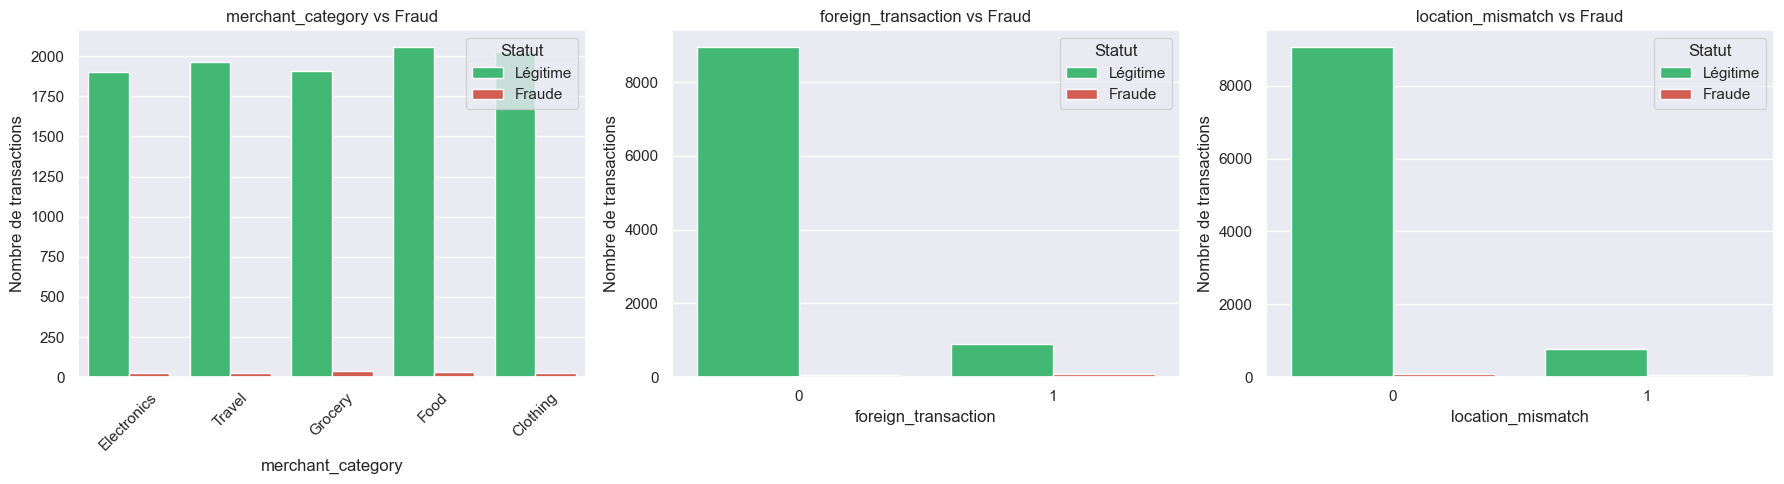

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(categorical_cols):
    
    sns.countplot(
        data=df,
        x=col,
        hue='is_fraud',
        ax=axes[i],
        palette=["#2ecc71", "#e74c3c"]
    )
    
    axes[i].set_title(f"{col} vs Fraud")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de transactions")
    axes[i].legend(title="Statut", labels=["Légitime", "Fraude"])
    
    # Rotation seulement si beaucoup de catégories
    if col == 'merchant_category':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

                   sum  count      mean  fraud_rate
merchant_category                                  
Clothing            24   2050  0.011707    1.170732
Electronics         24   1923  0.012480    1.248050
Food                35   2093  0.016722    1.672241
Grocery             39   1944  0.020062    2.006173
Travel              29   1990  0.014573    1.457286
                     sum  count      mean  fraud_rate
foreign_transaction                                  
0                     69   9022  0.007648    0.764797
1                     82    978  0.083845    8.384458
                   sum  count      mean  fraud_rate
location_mismatch                                  
0                   79   9143  0.008640    0.864049
1                   72    857  0.084014    8.401400


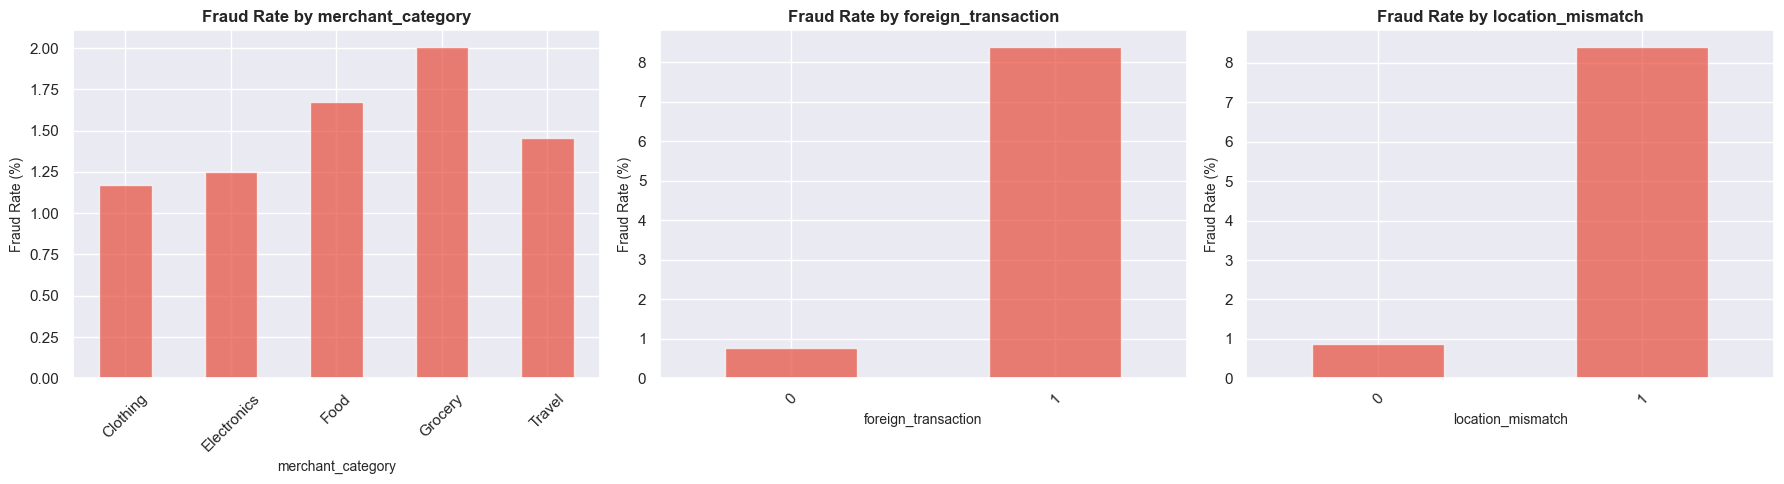

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(categorical_cols):
    fraud_rate = df.groupby(col)['is_fraud'].agg(['sum', 'count', 'mean'])
    fraud_rate['fraud_rate'] = fraud_rate['mean'] * 100
    
    fraud_rate['fraud_rate'].plot(kind='bar', ax=axes[idx], color='#e74c3c', alpha=0.7)
    axes[idx].set_title(f'Fraud Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Fraud Rate (%)', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [36]:
# STEP 1 - Clean the dataset
df = df.drop(["transaction_id"], axis=1)
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [37]:
numerical_features = [
    'amount',
    'transaction_hour',
    'device_trust_score',
    'velocity_last_24h',
    'cardholder_age',
    'foreign_transaction',
    'location_mismatch'
]

categorical_features = [
    'merchant_category'
]

In [44]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer



In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
print("✓ Preprocessor est créé avec succès")

✓ Preprocessor est créé avec succès


In [46]:
from imblearn.pipeline import Pipeline
def build_pipeline(model):
    return Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("Smote",SMOTE(random_state=42)),
        ("model", model)
    ])

In [47]:
logistic_pipeline = build_pipeline(LogisticRegression(max_iter=1000))
rf_pipeline = build_pipeline(RandomForestClassifier(n_estimators=100,n_jobs=-1, random_state=42))
xgb_pipeline = build_pipeline(xgb.XGBClassifier(eval_metric="logloss", random_state=42))
lgb_pipeline = build_pipeline(lgb.LGBMClassifier(random_state=42))

In [48]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [49]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [50]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [51]:
lgb_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 7879, number of negative: 7879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2611
[LightGBM] [Info] Number of data points in the train set: 15758, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,steps,"[('preprocessing', ...), ('Smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th


MODEL: Logistic Regression


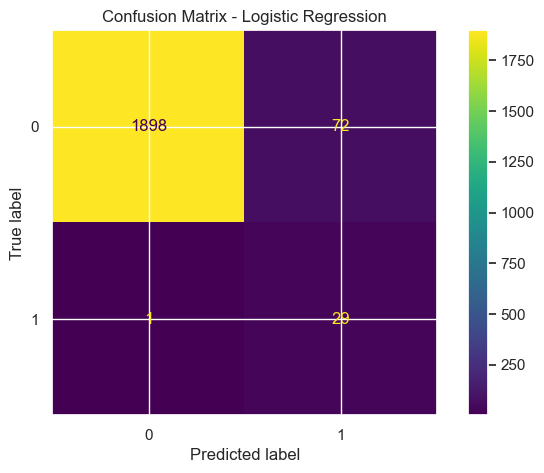


Confusion Matrix:
[[1898   72]
 [   1   29]]

--- Advanced Metrics ---
ROC AUC        : 0.9933
PR AUC         : 0.7451
Precision      : 0.2871
Recall (Fraud) : 0.9667
F1-Score       : 0.4427
Specificity    : 0.9635
False Pos Rate : 0.0365


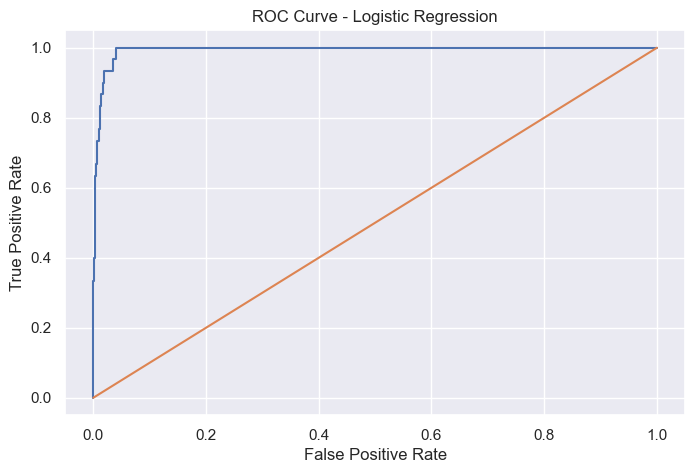

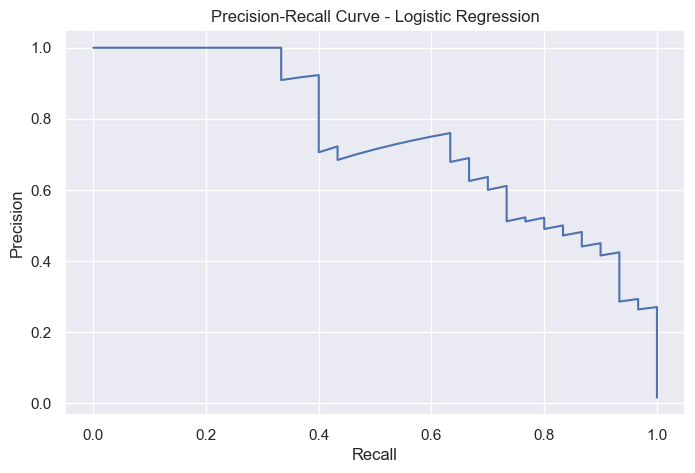


MODEL: Random Forest


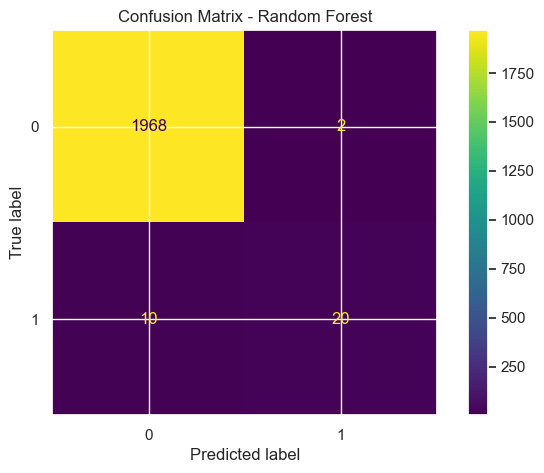


Confusion Matrix:
[[1968    2]
 [  10   20]]

--- Advanced Metrics ---
ROC AUC        : 0.9992
PR AUC         : 0.9515
Precision      : 0.9091
Recall (Fraud) : 0.6667
F1-Score       : 0.7692
Specificity    : 0.9990
False Pos Rate : 0.0010


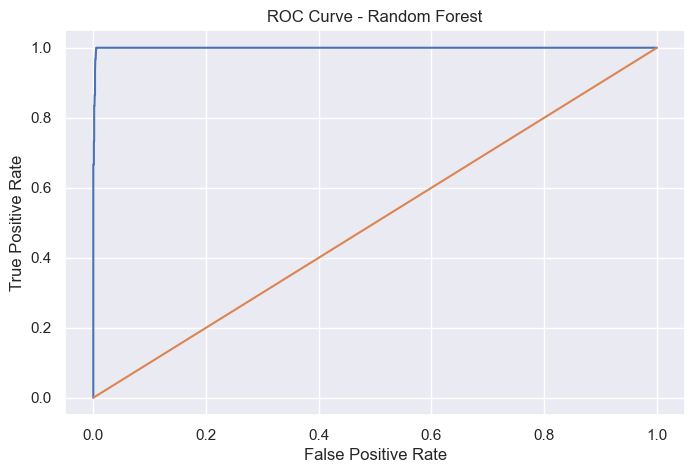

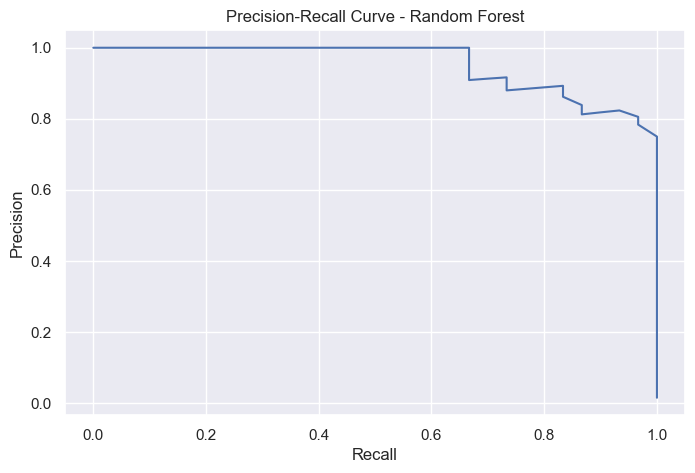


MODEL: XGBoost


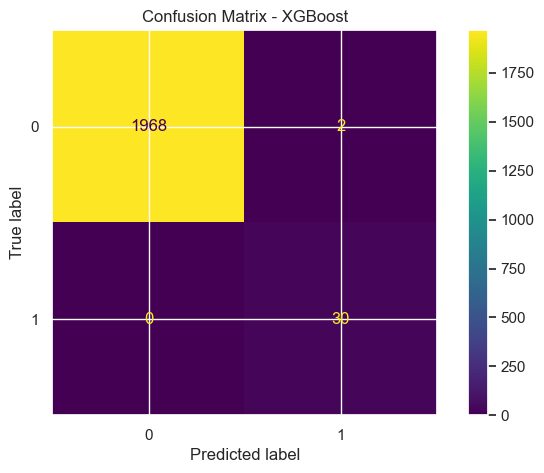


Confusion Matrix:
[[1968    2]
 [   0   30]]

--- Advanced Metrics ---
ROC AUC        : 0.9999
PR AUC         : 0.9957
Precision      : 0.9375
Recall (Fraud) : 1.0000
F1-Score       : 0.9677
Specificity    : 0.9990
False Pos Rate : 0.0010


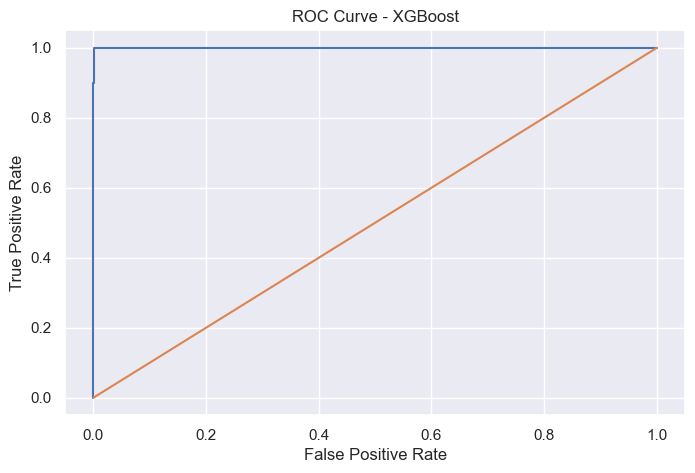

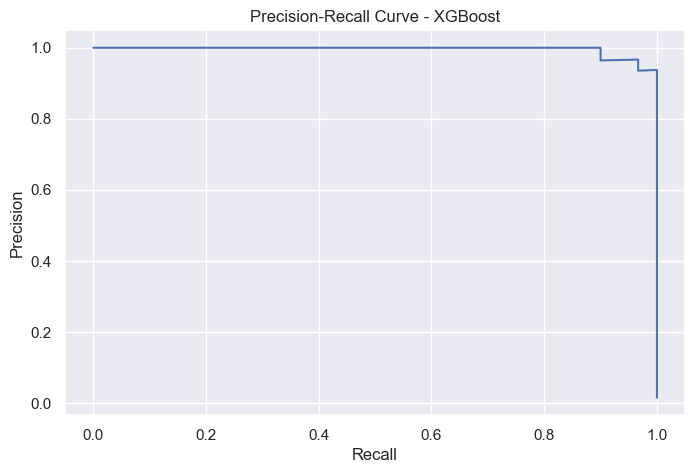


MODEL: LightGBM


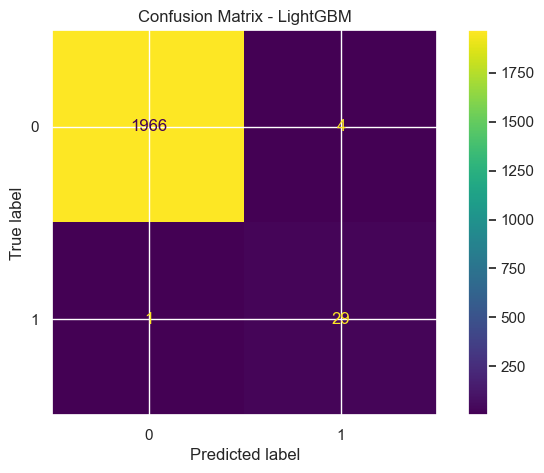


Confusion Matrix:
[[1966    4]
 [   1   29]]

--- Advanced Metrics ---
ROC AUC        : 0.9999
PR AUC         : 0.9939
Precision      : 0.8788
Recall (Fraud) : 0.9667
F1-Score       : 0.9206
Specificity    : 0.9980
False Pos Rate : 0.0020


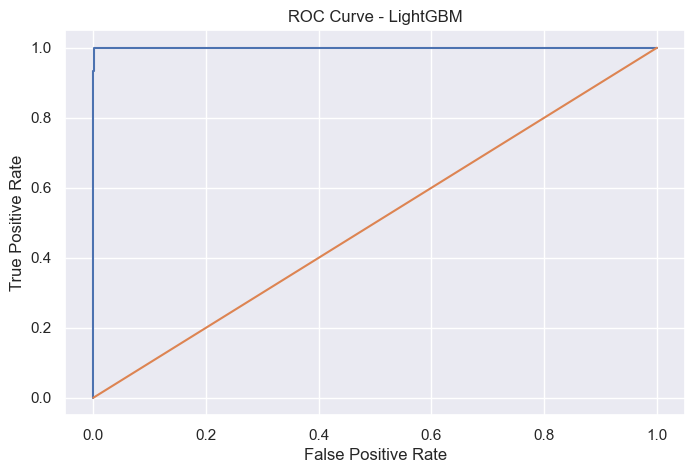

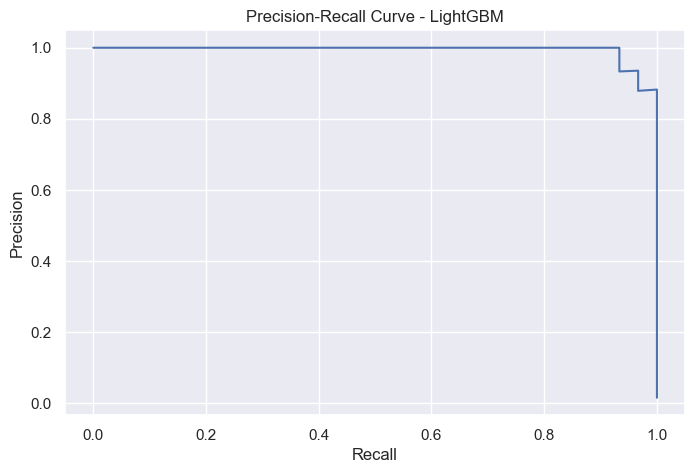


FINAL MODEL COMPARISON (Sorted by PR_AUC)


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Specificity,FPR
2,XGBoost,0.999932,0.995656,0.937500,1.000000,0.967742,0.998985,0.001015
3,LightGBM,0.999898,0.993928,0.878788,0.966667,0.920635,0.997970,0.002030
1,Random Forest,0.999239,0.951475,0.909091,0.666667,0.769231,0.998985,0.001015
0,Logistic Regression,0.993299,0.745106,0.287129,0.966667,0.442748,0.963452,0.036548


In [54]:
pipelines = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgb_pipeline
}

# PROFESSIONAL MODEL EVALUATION
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

evaluation_results = []

for name, model in pipelines.items():
    
    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)
    
  
    # 1️. Predictions
    
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # 2️. Core Metrics

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # 3️. Confusion Matrix Breakdown

    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP)          # True Negative Rate
    fpr = FP / (FP + TN)                  # False Positive Rate
    
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\n--- Advanced Metrics ---")
    print(f"ROC AUC        : {roc_auc:.4f}")
    print(f"PR AUC         : {pr_auc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall (Fraud) : {recall:.4f}")
    print(f"F1-Score       : {f1:.4f}")
    print(f"Specificity    : {specificity:.4f}")
    print(f"False Pos Rate : {fpr:.4f}")
    
    # Save results
    evaluation_results.append({
        "Model": name,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "FPR": fpr
    })
    

    # 4️. ROC Curve

    
    fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
    
    plt.figure()
    plt.plot(fpr_curve, tpr_curve)
    plt.plot([0,1],[0,1])
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()
    

    # 5️. Precision-Recall Curve (Very Important)

    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    
    plt.figure()
    plt.plot(recall_vals, precision_vals)
    plt.title(f"Precision-Recall Curve - {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()



# Global Comparison Table


results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(by="PR_AUC", ascending=False)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON (Sorted by PR_AUC)")
print("="*60)

display(results_df)

In [56]:
scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

from sklearn.model_selection import cross_validate

for name, model in pipelines.items():
    
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    
    print("\n" + "="*40)
    print(name)
    print("="*40)
    
    for metric in scoring.keys():
        print(f"{metric} mean : {cv_results['test_'+metric].mean():.4f}")


Logistic Regression
pr_auc mean : 0.6846
roc_auc mean : 0.9918
recall mean : 0.9075
precision mean : 0.3022
f1 mean : 0.4518

Random Forest
pr_auc mean : 0.9480
roc_auc mean : 0.9987
recall mean : 0.6692
precision mean : 0.9905
f1 mean : 0.7968

XGBoost
pr_auc mean : 0.9891
roc_auc mean : 0.9997
recall mean : 0.9669
precision mean : 0.9166
f1 mean : 0.9387

LightGBM
pr_auc mean : 0.9883
roc_auc mean : 0.9998
recall mean : 0.9735
precision mean : 0.9460
f1 mean : 0.9579


In [59]:
from sklearn.pipeline import Pipeline as Pipe  # sklearn version
production_pipeline = Pipe(steps=[
    ("preprocessing", preprocessor),
    ("model", xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])


In [60]:
production_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [62]:
import joblib

joblib.dump(production_pipeline, "fraud_model_production1.pkl")

['fraud_model_production1.pkl']